In [1]:
from sklearn.preprocessing import StandardScaler

from sklearn.mixture import GaussianMixture

import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("/Users/avatarvaleria/Projects/colabs/ed-prj/ed-backend/carelog/ml/v2_synthetic_tracking_data.csv")
df_features = df.iloc[:, 1:]
print(df_features[:5])

   urge_intensity  binge_urge  restriction_urge  emotional_distress  \
0             4.9         2.2               9.2                 9.6   
1             7.0         1.3               9.3                 8.5   
2             7.1         7.5               2.5                 7.7   
3             4.0         3.7               2.1                 4.2   
4             1.2         0.2               3.5                 1.7   

   stress_level  energy_level  sleep_hours  num_meals  exercise_minutes  
0           7.6           3.5          7.9        0.9               0.0  
1           7.0           5.3          8.3        1.5              16.5  
2           8.2           5.4          3.9        4.9              17.0  
3           3.4           1.2          6.2        2.9              11.7  
4           1.9           6.2          6.7        3.1              38.7  


In [3]:
gmm_scaler = StandardScaler()
features_scaled = gmm_scaler.fit_transform(df_features)

In [4]:
#visualizing data
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

In [5]:
X_pca = pca.fit_transform(features_scaled)

In [6]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_)

[0.38303658 0.34393855]
[3.45078    3.09854554]


In [7]:
gmm = GaussianMixture(n_components=4, covariance_type='diag', random_state=42)

gmm.fit(features_scaled)

,"n_components n_components: int, default=1The number of mixture components.",4
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'diag'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [8]:
df_features["cluster"] = gmm.predict(features_scaled)

In [9]:
cluster_labels = df_features["cluster"]

In [10]:
group_clusters = df_features.groupby("cluster")
group_means = group_clusters.mean()

In [11]:
group_means

,urge_intensity,binge_urge,restriction_urge,emotional_distress,stress_level,energy_level,sleep_hours,num_meals,exercise_minutes
cluster,,,,,,,,,
0,5.998367,2.070204,9.042857,8.962857,8.000000,3.988980,8.474694,1.479592,43.469388
1,2.061446,1.047791,3.067470,1.989960,2.916867,6.961044,7.445382,2.987550,29.549398
2,4.019087,3.046888,3.095021,3.968050,4.977593,1.961411,5.903734,2.470539,10.819917
3,6.961132,7.986415,3.001132,6.965283,8.050943,5.996604,4.495472,4.988679,25.661132


In [12]:
STATE_NAMES = {
    0: "emotional distress + restriction",
    1: "stable",
    2: "burnout/being numb",
    3: "emotional distress + binge/overeating"
}

In [13]:
df_features["state_name"] = df_features["cluster"].map(STATE_NAMES)
state_name = df_features["state_name"]

In [14]:
print(state_name[0:10])

0         emotional distress + restriction
1         emotional distress + restriction
2    emotional distress + binge/overeating
3                       burnout/being numb
4                                   stable
5    emotional distress + binge/overeating
6    emotional distress + binge/overeating
7         emotional distress + restriction
8                                   stable
9                                   stable
Name: state_name, dtype: object


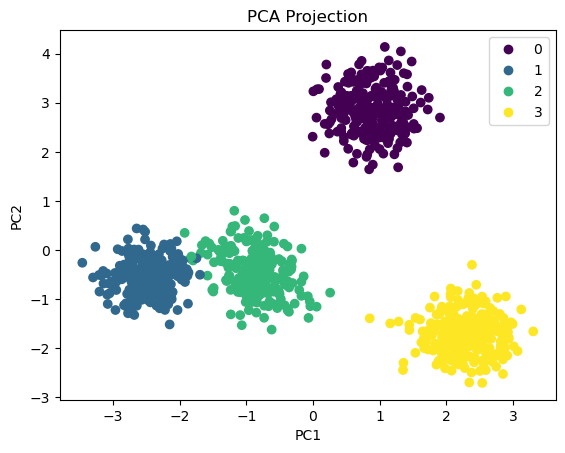

In [15]:
import matplotlib.pyplot as plt

plot = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.legend(*plot.legend_elements())
plt.show()

## TESTING

In [ ]:
#testing data
df_testing = pd.read_csv("/Users/avatarvaleria/Projects/colabs/ed-prj/ed-backend/carelog/ml/v2_test_tracking_data.csv")
df_test_features = df_testing.iloc[:, 1:]
print(df_test_features[:5])

   urge_intensity  binge_urge  restriction_urge  emotional_distress  \
0             5.7         2.2               9.3                 9.7   
1             8.1         1.4               9.4                 8.4   
2             7.1         8.5               2.5                 8.7   
3             2.0         3.6               1.3                 4.2   
4             1.3         0.9               3.5                 1.7   

   stress_level  energy_level  sleep_hours  num_meals  exercise_minutes  
0           7.4           3.5          7.4        0.9               0.0  
1           6.6           5.3          7.8        1.5               9.4  
2           9.3           4.4          3.4        4.9              19.7  
3           4.2           1.2          6.2        2.4              11.7  
4           1.9           7.4          6.9        3.1              53.7  


In [31]:
test_features_scaled = gmm_scaler.fit_transform(df_test_features)
print(test_features_scaled[:5])

[[ 0.44952293 -0.6626002   1.8934372   1.42354803  0.42163009 -0.55561378
   0.54898789 -1.4619937  -1.4061968 ]
 [ 1.35157563 -0.92777286  1.93032474  0.96818079  0.09729925  0.24191796
   0.76136232 -1.04977743 -0.95217983]
 [ 0.97572034  1.42563454 -0.61491522  1.07326554  1.19191583 -0.15684791
  -1.57475637  1.28611475 -0.45469316]
 [-0.94114165 -0.19854803 -1.05756565 -0.50300565 -0.87569327 -1.57468213
  -0.08813539 -0.43145303 -0.84109058]
 [-1.20424036 -1.09350578 -0.24603986 -1.37871187 -1.80814443  1.17237167
   0.28351986  0.04946595  1.18749586]]


In [32]:
df_test_features["cluster_pred"] = gmm.predict(test_features_scaled)
df_test_features["state_name_pred"] = df_test_features["cluster_pred"].map(STATE_NAMES)

In [33]:
df_test_features[:10]

,urge_intensity,binge_urge,restriction_urge,emotional_distress,stress_level,energy_level,sleep_hours,num_meals,exercise_minutes,cluster_pred,state_name_pred
0,5.7,2.2,9.3,9.7,7.4,3.5,7.4,0.9,0.0,0,emotional distress + restriction
1,8.1,1.4,9.4,8.4,6.6,5.3,7.8,1.5,9.4,0,emotional distress + restriction
2,7.1,8.5,2.5,8.7,9.3,4.4,3.4,4.9,19.7,3,emotional distress + binge/overeating
3,2.0,3.6,1.3,4.2,4.2,1.2,6.2,2.4,11.7,2,burnout/being numb
4,1.3,0.9,3.5,1.7,1.9,7.4,6.9,3.1,53.7,1,stable
5,7.9,8.2,2.7,8.2,9.9,4.6,3.9,4.2,13.0,3,emotional distress + binge/overeating
6,7.8,9.3,2.1,7.9,9.9,5.7,4.9,5.2,58.7,3,emotional distress + binge/overeating
7,5.9,2.1,8.6,9.1,6.0,3.8,8.4,2.4,32.0,0,emotional distress + restriction
8,1.9,1.7,3.3,2.7,3.2,8.2,9.4,3.1,40.4,1,stable
9,2.5,1.7,2.1,2.2,3.2,8.0,7.8,1.9,38.7,1,stable


In [36]:
test_pca = PCA(n_components=2)
X_test_pca = test_pca.fit_transform(test_features_scaled)

In [37]:
print(test_pca.explained_variance_ratio_)
print(test_pca.explained_variance_)

[0.42981241 0.27265663]
[3.90738556 2.47869665]


In [38]:
df_test_features["cluster_pred"] = gmm.predict(test_features_scaled)
df_test_features["state_name_pred"] = df_test_features["cluster_pred"].map(STATE_NAMES)

In [39]:
df_test_features[:10]

,urge_intensity,binge_urge,restriction_urge,emotional_distress,stress_level,energy_level,sleep_hours,num_meals,exercise_minutes,cluster_pred,state_name_pred
0,5.7,2.2,9.3,9.7,7.4,3.5,7.4,0.9,0.0,0,emotional distress + restriction
1,8.1,1.4,9.4,8.4,6.6,5.3,7.8,1.5,9.4,0,emotional distress + restriction
2,7.1,8.5,2.5,8.7,9.3,4.4,3.4,4.9,19.7,3,emotional distress + binge/overeating
3,2.0,3.6,1.3,4.2,4.2,1.2,6.2,2.4,11.7,2,burnout/being numb
4,1.3,0.9,3.5,1.7,1.9,7.4,6.9,3.1,53.7,1,stable
5,7.9,8.2,2.7,8.2,9.9,4.6,3.9,4.2,13.0,3,emotional distress + binge/overeating
6,7.8,9.3,2.1,7.9,9.9,5.7,4.9,5.2,58.7,3,emotional distress + binge/overeating
7,5.9,2.1,8.6,9.1,6.0,3.8,8.4,2.4,32.0,0,emotional distress + restriction
8,1.9,1.7,3.3,2.7,3.2,8.2,9.4,3.1,40.4,1,stable
9,2.5,1.7,2.1,2.2,3.2,8.0,7.8,1.9,38.7,1,stable


In [40]:
state_original = df_testing.iloc[:, 0]
state_original

0     1
1     1
2     2
3     3
4     0
     ..
95    1
96    3
97    1
98    1
99    0
Name: latent_state, Length: 100, dtype: int64

In [41]:
df_test_features["state_original"] = state_original


In [42]:
df_test_features[:10]

,urge_intensity,binge_urge,restriction_urge,emotional_distress,stress_level,energy_level,sleep_hours,num_meals,exercise_minutes,cluster_pred,state_name_pred,state_original
0,5.7,2.2,9.3,9.7,7.4,3.5,7.4,0.9,0.0,0,emotional distress + restriction,1
1,8.1,1.4,9.4,8.4,6.6,5.3,7.8,1.5,9.4,0,emotional distress + restriction,1
2,7.1,8.5,2.5,8.7,9.3,4.4,3.4,4.9,19.7,3,emotional distress + binge/overeating,2
3,2.0,3.6,1.3,4.2,4.2,1.2,6.2,2.4,11.7,2,burnout/being numb,3
4,1.3,0.9,3.5,1.7,1.9,7.4,6.9,3.1,53.7,1,stable,0
5,7.9,8.2,2.7,8.2,9.9,4.6,3.9,4.2,13.0,3,emotional distress + binge/overeating,2
6,7.8,9.3,2.1,7.9,9.9,5.7,4.9,5.2,58.7,3,emotional distress + binge/overeating,2
7,5.9,2.1,8.6,9.1,6.0,3.8,8.4,2.4,32.0,0,emotional distress + restriction,1
8,1.9,1.7,3.3,2.7,3.2,8.2,9.4,3.1,40.4,1,stable,0
9,2.5,1.7,2.1,2.2,3.2,8.0,7.8,1.9,38.7,1,stable,0


In [43]:
df_test_features["state_name_original"] = df_test_features["cluster_pred"].map(STATE_NAMES)
#state_name_original = df_features["state_name_original"]
df_test_features[:10]

,urge_intensity,binge_urge,restriction_urge,emotional_distress,stress_level,energy_level,sleep_hours,num_meals,exercise_minutes,cluster_pred,state_name_pred,state_original,state_name_original
0,5.7,2.2,9.3,9.7,7.4,3.5,7.4,0.9,0.0,0,emotional distress + restriction,1,emotional distress + restriction
1,8.1,1.4,9.4,8.4,6.6,5.3,7.8,1.5,9.4,0,emotional distress + restriction,1,emotional distress + restriction
2,7.1,8.5,2.5,8.7,9.3,4.4,3.4,4.9,19.7,3,emotional distress + binge/overeating,2,emotional distress + binge/overeating
3,2.0,3.6,1.3,4.2,4.2,1.2,6.2,2.4,11.7,2,burnout/being numb,3,burnout/being numb
4,1.3,0.9,3.5,1.7,1.9,7.4,6.9,3.1,53.7,1,stable,0,stable
5,7.9,8.2,2.7,8.2,9.9,4.6,3.9,4.2,13.0,3,emotional distress + binge/overeating,2,emotional distress + binge/overeating
6,7.8,9.3,2.1,7.9,9.9,5.7,4.9,5.2,58.7,3,emotional distress + binge/overeating,2,emotional distress + binge/overeating
7,5.9,2.1,8.6,9.1,6.0,3.8,8.4,2.4,32.0,0,emotional distress + restriction,1,emotional distress + restriction
8,1.9,1.7,3.3,2.7,3.2,8.2,9.4,3.1,40.4,1,stable,0,stable
9,2.5,1.7,2.1,2.2,3.2,8.0,7.8,1.9,38.7,1,stable,0,stable


In [44]:
matches = (df_test_features["state_name_pred"] == df_test_features["state_name_original"]).sum()
matches_percent = (matches/100) * 100
print(f"Percentage of matches: {matches_percent}")

Percentage of matches: 100.0


In [45]:
my_test_scaler = gmm_scaler.transform([[1.3,2.0,4.5,1.9,3.2,8.0,6.8,3.9,56.3]])
print(f'Pred: {gmm.predict(my_test_scaler)}')
print(f'Probs: {gmm.predict_proba(my_test_scaler)}')

Pred: [1]
Probs: [[1.38376392e-61 1.00000000e+00 2.05212527e-30 1.97884181e-43]]


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## SERIALIZING MODEL

In [46]:
import joblib

joblib.dump(gmm, "v2_gmm_model_updated3_features_diag.pkl")
joblib.dump(gmm_scaler, "v2_scaler_gmm_diag_updated3_features.pkl")

['v2_scaler_gmm_diag_updated3_features.pkl']